<a href="https://colab.research.google.com/github/scottspurlock/csc4422-s2026/blob/main/labs/day20_lab_embeddings_spurlock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DMML Day 20 Lab: Word Embeddings

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


## Wine Reviews

In [ ]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1MmVD9CDKSf9EYjjEkCwqEJDyrf1Y_fzq')
df.head()

,country,description,designation,points,price,province,region_1,region_2,variety,winery
0,US,This tremendous 100% varietal wine hails from ...,Martha's Vineyard,96,235.0,California,Napa Valley,Napa,Cabernet Sauvignon,Heitz
1,Spain,"Ripe aromas of fig, blackberry and cassis are ...",Carodorum Selección Especial Reserva,96,110.0,Northern Spain,Toro,NaN,Tinta de Toro,Bodega Carmen Rodríguez
2,US,Mac Watson honors the memory of a wine once ma...,Special Selected Late Harvest,96,90.0,California,Knights Valley,Sonoma,Sauvignon Blanc,Macauley
3,US,"This spent 20 months in 30% new French oak, an...",Reserve,96,65.0,Oregon,Willamette Valley,Willamette Valley,Pinot Noir,Ponzi
4,France,"This is the top wine from La Bégude, named aft...",La Brûlade,95,66.0,Provence,Bandol,NaN,Provence red blend,Domaine de la Bégude


In [ ]:
# input data is reviews
X = df['description']
y = df['price']

# turn price into 0's and 1's for classification
med_price = df['price'].median()
mask = df['price'] > med_price
y = mask.astype(int)
y.value_counts()

,count
price,
0,1078
1,922


## Vectorize

In [ ]:
# Configure TextVectorization
# We use this instead of our home-grown tokenizer from day 17
vectorizer = tf.keras.layers.TextVectorization(
    standardize="lower_and_strip_punctuation",
    output_mode="int" # could be tf_idf
)

# our corpus is the wine reviews in X
vectorizer.adapt(X)

In [ ]:
len(vectorizer.get_vocabulary())

5956

In [ ]:
# make dictionary to look up words later
vocab = vectorizer.get_vocabulary()
vocab_size = len(vocab)

word_to_index = {}
for i, word in enumerate(vocab):
    word_to_index[word] = i

print(f"Vocabulary Size: {vocab_size}")
print(f"Vocabulary: {word_to_index}")

Vocabulary Size: 5956
Vocabulary: {'': 0, '[UNK]': 1, np.str_('and'): 2, np.str_('the'): 3, np.str_('of'): 4, np.str_('a'): 5, np.str_('this'): 6, np.str_('with'): 7, np.str_('is'): 8, np.str_('wine'): 9, np.str_('in'): 10, np.str_('flavors'): 11, np.str_('it'): 12, np.str_('to'): 13, np.str_('on'): 14, np.str_('palate'): 15, np.str_('its'): 16, np.str_('from'): 17, np.str_('aromas'): 18, np.str_('drink'): 19, np.str_('fruit'): 20, np.str_('tannins'): 21, np.str_('black'): 22, np.str_('acidity'): 23, np.str_('finish'): 24, np.str_('cherry'): 25, np.str_('that'): 26, np.str_('ripe'): 27, np.str_('are'): 28, np.str_('but'): 29, np.str_('by'): 30, np.str_('has'): 31, np.str_('red'): 32, np.str_('for'): 33, np.str_('plum'): 34, np.str_('fresh'): 35, np.str_('nose'): 36, np.str_('oak'): 37, np.str_('berry'): 38, np.str_('as'): 39, np.str_('offers'): 40, np.str_('rich'): 41, np.str_('fruits'): 42, np.str_('through'): 43, np.str_('an'): 44, np.str_('spice'): 45, np.str_('notes'): 46, np.str_(

## CBoW Data

In [ ]:
window_size = 2
Xtrain = []
ytrain = []

# Vectorize the entire corpus first
vectorized_corpus = vectorizer(np.array(X)).numpy()

for seq in vectorized_corpus:
    # Filter out padding (0) if sentences are different lengths
    seq = [idx for idx in seq if idx != 0]

    for i in range(window_size, len(seq) - window_size):
        context = seq[i - window_size : i] + seq[i + 1 : i + window_size + 1]
        target = seq[i]
        Xtrain.append(context)
        ytrain.append(target)

Xtrain = np.array(Xtrain)
ytrain = np.array(ytrain)

In [ ]:
Xtrain[0]

array([   6, 1161,  353,    9])

In [ ]:
ytrain[0]

np.int64(294)

## CBoW model architecture

In [ ]:
embedding_dim = 16

model = tf.keras.models.Sequential([
    # Input is the window of context words (window_size * 2)
    tf.keras.layers.Input(shape=(window_size * 2,)),

    # The Embedding Layer: This is what we actually want to learn!
    # Turns nonnegative integers (indexes) into vectors of fixed size.
    # Output will be (None, window_size * 2, embedding_dim)
    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, name="w2v_embedding"),

    # Average the context word vectors (The "Bag of Words" part)
    # Output will be (None, embedding_dim)
    tf.keras.layers.GlobalAveragePooling1D(),

    # Predict the target word
    # Output will be (None, vocab_size)
    # which can be interpreted as a probability distribution
    # over the possible vocabulary words
    tf.keras.layers.Dense(vocab_size, activation='softmax')
])

opt = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=opt, loss='sparse_categorical_crossentropy')

## training loop

In [ ]:
history = model.fit(Xtrain, ytrain, epochs=20, verbose=1)

Epoch 1/20
2374/2374 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 5.9759
Epoch 2/20
2374/2374 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 4.9898
Epoch 3/20
2374/2374 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 4.5778
Epoch 4/20
2374/2374 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 4.3310
Epoch 5/20
2374/2374 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 4.1590
Epoch 6/20
2374/2374 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 4.0307
Epoch 7/20
2374/2374 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 3.9290
Epoch 8/20
2374/2374 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 3.8491
Epoch 9/20
2374/2374 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 3.7809
Epoch 10/20
2374/2374 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 3.7268
Epoch 11/20
2374/2374 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 3.6807
Epoch 12/20
2374/2374 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 3.6424
Epoch 13/20
2374/2374 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 3.6093
Epoch 14/20
2374/2374 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 3.5815
Epoch 15/20
2374/2374 ━━━━━━━

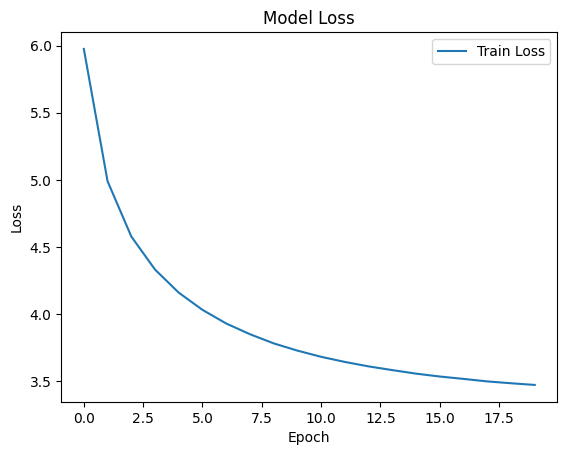

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

## Similarity of word embeddings

In [ ]:
# Extract the weights from the embedding layer
weights = model.get_layer("w2v_embedding").get_weights()[0]
print(weights.shape)


(5956, 16)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def compare_words(word_a, word_b):
    vec_a = weights[word_to_index[word_a]]
    vec_b = weights[word_to_index[word_b]]
    similarity = cosine_similarity([vec_a], [vec_b])

    # similarity is a list of lists for some reason
    return similarity[0][0]

# Demo matches
a = 'soft'
b = 'smooth'
sim = compare_words(a, b)
print(f"Similarity between '{a}' and '{b}': {sim:.4f}")

a = 'earthy'
b = 'drink'
sim = compare_words(a, b)
print(f"Similarity between '{a}' and '{b}': {sim:.4f}")

a = 'excellent'
b = 'bad'
sim = compare_words(a, b)
print(f"Similarity between '{a}' and '{b}': {sim:.4f}")


Similarity between 'soft' and 'smooth': 0.8075
Similarity between 'earthy' and 'drink': -0.2759
Similarity between 'excellent' and 'bad': 0.3173


## Use the word embeddings in a classifier

In [ ]:
# Extract the weights from the embedding layer
learned_weights = model.get_layer("w2v_embedding").get_weights()[0]

# get info from the vectorizer layer
vocab = vectorizer.get_vocabulary()

# Build the Classifier
classifier_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,), dtype=tf.string),
    tf.keras.layers.TextVectorization(vocabulary=vocab), # Use same vocab
    tf.keras.layers.Embedding(vocab_size, embedding_dim, weights=learned_weights, trainable=False),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax') # low, high
])

opt = tf.keras.optimizers.Adam(learning_rate=0.0001)
classifier_model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=1)


In [ ]:
# TensorFlow likes its own variable type
Xtrain = tf.Variable(Xtrain)
ytrain = tf.Variable(ytrain)
Xtest = tf.Variable(Xtest)
ytest = tf.Variable(ytest)


In [ ]:
# Train the model
history = classifier_model.fit(
    Xtrain,
    ytrain,
    epochs=20,
    batch_size=2,
    verbose=1,
    validation_split=0.2
)

Epoch 1/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4906 - loss: 0.7075 - val_accuracy: 0.5188 - val_loss: 0.6987
Epoch 2/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5578 - loss: 0.6878 - val_accuracy: 0.5531 - val_loss: 0.6850
Epoch 3/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6148 - loss: 0.6747 - val_accuracy: 0.5844 - val_loss: 0.6739
Epoch 4/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6484 - loss: 0.6621 - val_accuracy: 0.6062 - val_loss: 0.6646
Epoch 5/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6594 - loss: 0.6525 - val_accuracy: 0.6094 - val_loss: 0.6573
Epoch 6/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6641 - loss: 0.6452 - val_accuracy: 0.6125 - val_loss: 0.6514
Epoch 7/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6695 - loss: 0.6374 - val_accuracy: 0.6094 - val_loss: 0.6469
Epoch 8/20
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6656 - loss: 0.6317 - val_accuracy: 0.

In [ ]:
# predictions will have one column per possible class
preds = classifier_model(Xtest)
# find the predicted label using argmax
ypred = np.argmax(preds, axis=1)
ypred

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0,

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


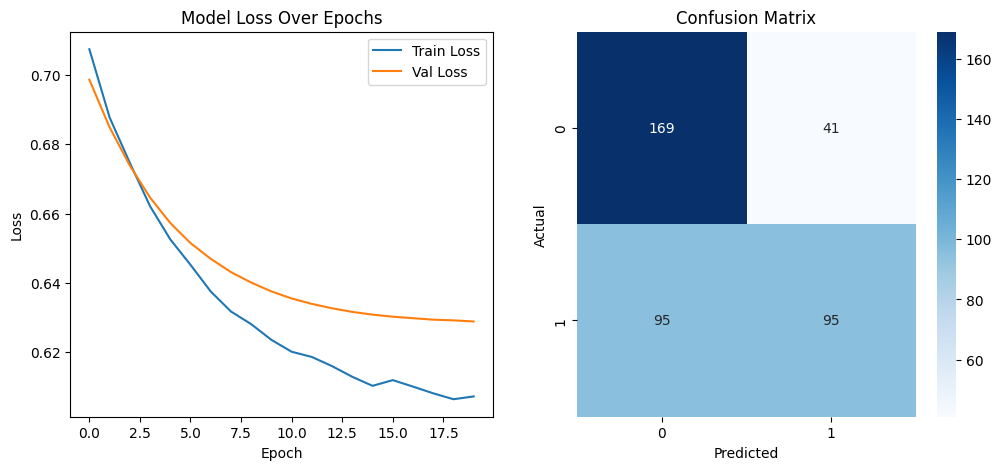

In [ ]:
# loss curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# confusion matrix
plt.subplot(1, 2, 2)

# note that the model has 3 outputs, which are probabilities for the classes
ypred_probs = classifier_model.predict(Xtest)

# Convert probs back to class index
ypred = np.argmax(ypred_probs, axis=1)

cm = confusion_matrix(ytest, ypred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0, 1], yticklabels=[0, 1])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
